# Load the Travily API

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [7]:
from langchain_community.tools.tavily_search import TavilySearchResults

travily = TavilySearchResults(max=3)

response = travily.invoke("what is transformer architecture?")

print(response)

/var/folders/1b/83xpzy2s1zz2hh1vm7mnkylm0000gn/T/ipykernel_1766/3924685078.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  travily = TavilySearchResults(max=3)


[{'title': 'LLM Transformer Model Visually Explained', 'url': 'https://poloclub.github.io/transformer-explainer', 'content': '1 / 20\n\n# What is a Transformer?\n\nTransformer is a neural network architecture that has fundamentally changed the approach to Artificial Intelligence. Transformer was first introduced in the seminal paper "Attention is All You Need" in 2017 and has since become the go-to architecture for deep learning models, powering text-generative models like OpenAI\'s GPT, Meta\'s Llama, and Google\'s Gemini. Beyond text, Transformer is also applied in audio generation, image recognition, protein structure prediction, and even game playing, demonstrating its versatility across numerous domains. [...] GPT-2 family of models are prominent examples of text-generative Transformers. Transformer Explainer is powered by the GPT-2 (small) model which has 124 million parameters. While it is not the latest or most powerful Transformer model, it shares many of the same architectura

In [1]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper


/var/folders/1b/83xpzy2s1zz2hh1vm7mnkylm0000gn/T/ipykernel_1766/3042291148.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun


In [2]:
arxiv_api=ArxivAPIWrapper(top_k_results=3,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=arxiv_api)
arxiv.name

'arxiv'

In [4]:
import arxiv as arxiv_module
arxiv_module.Client.query_url_format = "https://export.arxiv.org/api/query?{}"

In [5]:
arxiv.invoke("attention all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [6]:
wikipedia_api = WikipediaAPIWrapper(top_k_results=3,doc_content_chars_max=300)
wiki = WikipediaQueryRun(api_wrapper=wikipedia_api)
wiki.name

'wikipedia'

In [8]:
#combine the tools
tools=[arxiv,wiki,travily]

In [10]:
from langchain_groq import ChatGroq
llm = ChatGroq(model_name="qwen/qwen3-32b")
llm.invoke("hi")

AIMessage(content='<think>\nOkay, the user said "hi". That\'s a greeting. I need to respond appropriately. Since it\'s a simple greeting, I should keep it friendly and open. Maybe ask how they\'re doing or offer help. Let me check previous interactions to see the tone. No history, so just go with a standard friendly reply. Make sure it\'s welcoming and encourages them to ask questions or share what\'s on their mind.\n</think>\n\nHello! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 101, 'prompt_tokens': 9, 'total_tokens': 110, 'completion_time': 0.199953975, 'prompt_time': 0.000319215, 'queue_time': 0.048234785, 'total_time': 0.20027319}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ed18d-3a11-7fd3-9075-3e626a82a6a8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens

In [12]:
#binding wihth llm
tools_with_llm=llm.bind_tools(tools)

In [13]:
from pprint import pprint
from langchain_core.messages import HumanMessage,AIMessage

tools_with_llm.invoke([HumanMessage(content="what is AI")])



AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking "what is AI". I need to provide a clear and concise definition. Let me start by recalling that AI stands for Artificial Intelligence. It\'s a field of computer science focused on creating systems that can perform tasks requiring human intelligence.\n\nI should mention the key areas AI covers, like learning, reasoning, problem-solving, perception, and language understanding. Maybe include examples of applications such as machine learning, natural language processing, and robotics. Also, it\'s important to note that AI can be narrow (focused on specific tasks) or general (capable of any intellectual task a human can do). \n\nWait, do I need to check the latest developments? The user might want up-to-date info. But since the question is pretty fundamental, the core definition hasn\'t changed much. However, to ensure accuracy, maybe use the Wikipedia function to get a reliable source. Let me call the wi

In [15]:
tools_with_llm.invoke([HumanMessage(content="attention all you need")]).tool_calls

[{'name': 'arxiv',
  'args': {'query': 'Attention Is All You Need'},
  'id': 'qvmkzfvq8',
  'type': 'tool_call'}]

In [16]:
#state schema
from typing_extensions import TypedDict
from typing import Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

In [25]:
#Entire chatbot with tools
from IPython.display import display, Image
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

#node definition
def tool_calling_llm(state:State):
    return {"messages": [tools_with_llm.invoke(state["messages"])]}

#build graph
builder = StateGraph(State)

#add nodes

builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))


#add edges

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools",END)


#compile
graph = builder.compile()


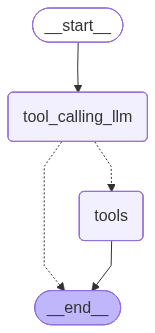

In [26]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [22]:
messages=graph.invoke({"messages":HumanMessage(content="what is attention all you need?")})
for message in messages['messages']:
    message.pretty_print()

================================ Human Message =================================

what is attention all you need?
================================== Ai Message ==================================
Tool Calls:
  arxiv (8k8pn0c27)
 Call ID: 8k8pn0c27
  Args:
    query: Attention Is All You Need
================================= Tool Message =================================
Name: arxiv

Published: 2021-05-06
Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: Luke Melas-Kyriazi
Summary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi


In [27]:
messages=graph.invoke({"messages":HumanMessage(content="what is attention ")})
for message in messages['messages']:
    message.pretty_print()

================================ Human Message =================================

what is attention 
================================== Ai Message ==================================
Tool Calls:
  wikipedia (2n76d5a94)
 Call ID: 2n76d5a94
  Args:
    query: Attention mechanism (machine learning)
================================= Tool Message =================================
Name: wikipedia

Page: Attention (machine learning)
Summary: In machine learning, attention is a method that determines the importance of each component in a sequence relative to the other components in that sequence. In natural language processing, importance is represented by "soft" weights assigned to each word i


In [28]:
messages=graph.invoke({"messages":HumanMessage(content=" what are the Stocks new top 3 on feb ")})
for message in messages['messages']:
    message.pretty_print()

================================ Human Message =================================

 what are the Stocks new top 3 on feb 
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (x7zapgs5e)
 Call ID: x7zapgs5e
  Args:
    query: new top 3 stocks February
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "The Only 3 Stocks I’d Consider Buying in February 2026", "url": "https://ca.finance.yahoo.com/news/only-3-stocks-d-consider-210000220.html", "content": "Here are three companies that are right near the top of my watch list in February 2026.\n\n## Alimentation Couche-Tard\n\nOne of my top defensive picks in the market right now for investors who are a bit unnerved by the increasing volatility and uncertainty we’re seeing in some asset classes is Alimentation Couche-Tard (TSX:ATD).\n\nThat’s partly due to the underlying business model Couche-Tard pr